## gwModelRemS : remnant properties of non-precessing quasi-circular BBH mergers

`gwModelRemS` predicts five remnant quantities from the mass ratio and the two
aligned spins $(q, \chi_{1z}, \chi_{2z})$:

| Quantity | Function | Units |
|---|---|---|
| Final mass $M_f/M$ | `gwModelRemS_mf` | dimensionless |
| Final spin $\chi_{f,z}$ | `gwModelRemS_chif` | dimensionless, signed |
| Peak luminosity $L_{\rm peak}$ | `gwModelRemS_Lpeak` | geometric, $c^5/G$ |
| Peak GW frequency $M\omega_{\rm peak}$ | `gwModelRemS_omega_peak` | dimensionless |
| Recoil $v_{\rm kick}$ | `gwModelRemS_kick` | km/s |

`gwModelRemS(q, chi1z, chi2z)` returns all five at once. The model is calibrated
to NR (SXS, RIT, Maya) and BHPT simulations over $1 \le q \lesssim 1000$ and
$|\chi_{iz}| \le 1$.

---

**Reference:** Islam, Wadekar & Khanna (2026), [arXiv:2608.00934](https://arxiv.org/abs/2608.00934)

In [1]:
import sys
!{sys.executable} -m pip install -e ../ --no-deps --quiet

import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import gwModels
gwModels.utils.set_rcparams()

lal.MSUN_SI != Msun


### 1. Basic evaluation

In [2]:
q, chi1z, chi2z = 3.0, 0.5, -0.2

Mf, chif, Lpeak, wpeak, vkick = gwModels.remnants.gwModelRemS(q, chi1z, chi2z)

print(f'q = {q}, chi1z = {chi1z}, chi2z = {chi2z}')
print(f'  Mf/M            = {Mf:.6f}')
print(f'  chi_f,z         = {chif:.6f}')
print(f'  L_peak [c^5/G]  = {Lpeak:.6e}')
print(f'  M omega_peak    = {wpeak:.6f}')
print(f'  v_kick [km/s]   = {vkick:.3f}')

q = 3.0, chi1z = 0.5, chi2z = -0.2
  Mf/M            = 0.961276
  chi_f,z         = 0.749482
  L_peak [c^5/G]  = 6.988052e-04
  M omega_peak    = 0.373187
  v_kick [km/s]   = 73.039


In [3]:
# Individual quantities, and full vectorization over any input
q_arr = np.array([1.0, 2.0, 4.0, 10.0, 100.0, 1000.0])

Mf = gwModels.remnants.gwModelRemS_mf(q_arr, 0.5, 0.0)
chif = gwModels.remnants.gwModelRemS_chif(q_arr, 0.5, 0.0)

for qi, mi, ci in zip(q_arr, Mf, chif):
    print(f'  q = {qi:7.1f} :  Mf/M = {mi:.6f}   chi_f = {ci:.6f}')

  q =     1.0 :  Mf/M = 0.943877   chi_f = 0.760850
  q =     2.0 :  Mf/M = 0.949876   chi_f = 0.778639
  q =     4.0 :  Mf/M = 0.968283   chi_f = 0.729315
  q =    10.0 :  Mf/M = 0.987226   chi_f = 0.636518
  q =   100.0 :  Mf/M = 0.999090   chi_f = 0.518992
  q =  1000.0 :  Mf/M = 0.999917   chi_f = 0.501976


### 2. Behaviour across the mass-ratio range\n\nThe model interpolates smoothly between the equal-mass and point-particle regimes. As $q \to \infty$ the remnant retains essentially all the mass and the spin approaches the primary's.

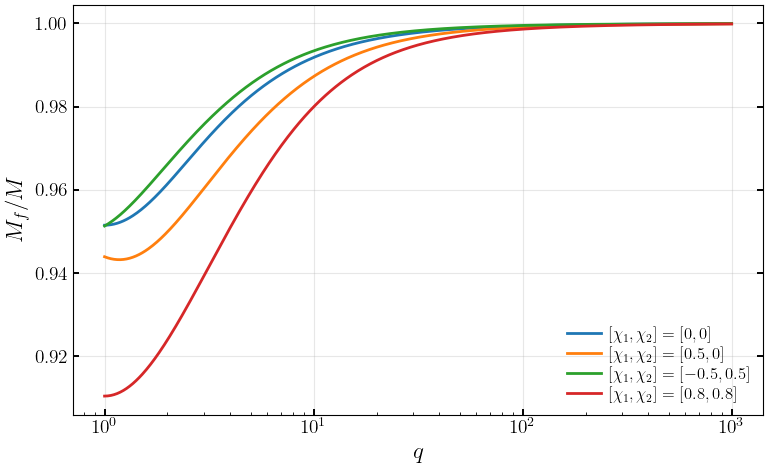

In [4]:
q_plot = np.logspace(0, 3, 600)

plt.figure(figsize=(8, 5))
for chi1z, chi2z, label in [
    (0.0, 0.0, r'$[\chi_1,\chi_2]=[0,0]$'),
    (0.5, 0.0, r'$[\chi_1,\chi_2]=[0.5,0]$'),
    (-0.5, 0.5, r'$[\chi_1,\chi_2]=[-0.5,0.5]$'),
    (0.8, 0.8, r'$[\chi_1,\chi_2]=[0.8,0.8]$'),
]:
    Mf = gwModels.remnants.gwModelRemS_mf(q_plot, chi1z, chi2z)
    plt.semilogx(q_plot, Mf, lw=2, label=label)

plt.xlabel('$q$')
plt.ylabel('$M_f/M$')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

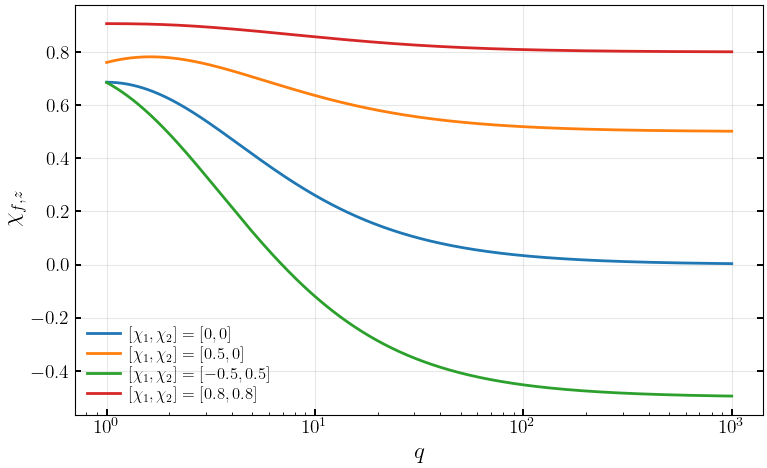

In [5]:
plt.figure(figsize=(8, 5))
for chi1z, chi2z, label in [
    (0.0, 0.0, r'$[\chi_1,\chi_2]=[0,0]$'),
    (0.5, 0.0, r'$[\chi_1,\chi_2]=[0.5,0]$'),
    (-0.5, 0.5, r'$[\chi_1,\chi_2]=[-0.5,0.5]$'),
    (0.8, 0.8, r'$[\chi_1,\chi_2]=[0.8,0.8]$'),
]:
    chif = gwModels.remnants.gwModelRemS_chif(q_plot, chi1z, chi2z)
    plt.semilogx(q_plot, chif, lw=2, label=label)

plt.xlabel('$q$')
plt.ylabel(r'$\chi_{f,z}$')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

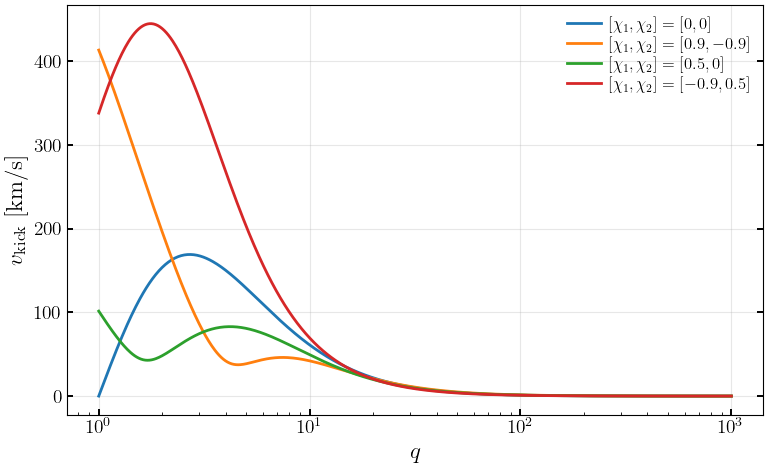

In [6]:
# Recoil velocity: peaks at intermediate mass ratio, vanishes at both ends
plt.figure(figsize=(8, 5))
for chi1z, chi2z, label in [
    (0.0, 0.0, r'$[\chi_1,\chi_2]=[0,0]$'),
    (0.9, -0.9, r'$[\chi_1,\chi_2]=[0.9,-0.9]$'),
    (0.5, 0.0, r'$[\chi_1,\chi_2]=[0.5,0]$'),
    (-0.9, 0.5, r'$[\chi_1,\chi_2]=[-0.9,0.5]$'),
]:
    vk = gwModels.remnants.gwModelRemS_kick(q_plot, chi1z, chi2z)
    plt.semilogx(q_plot, vk, lw=2, label=label)

plt.xlabel('$q$')
plt.ylabel(r'$v_{\rm kick}$ [km/s]')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

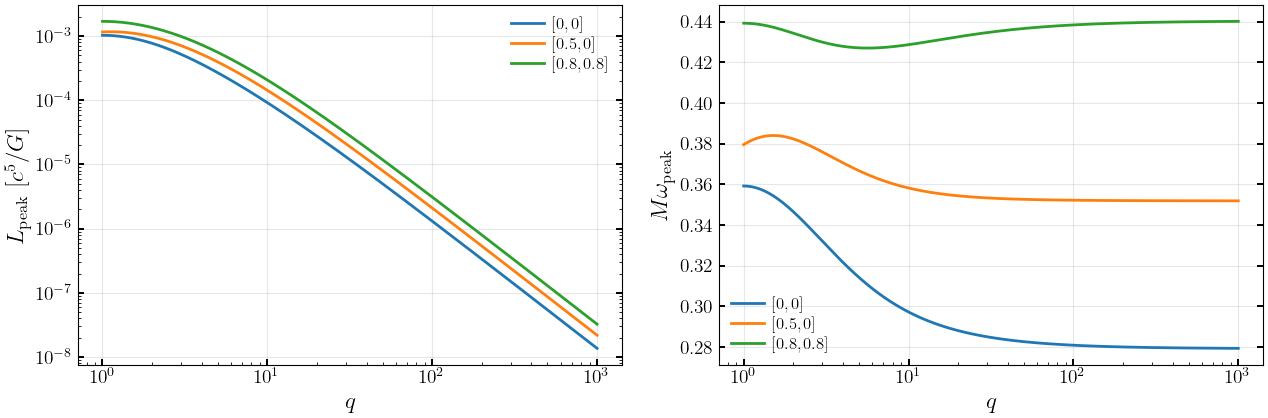

In [7]:
# Peak luminosity and peak frequency
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for chi1z, chi2z, label in [
    (0.0, 0.0, r'$[0,0]$'),
    (0.5, 0.0, r'$[0.5,0]$'),
    (0.8, 0.8, r'$[0.8,0.8]$'),
]:
    axes[0].loglog(q_plot, gwModels.remnants.gwModelRemS_Lpeak(q_plot, chi1z, chi2z),
                   lw=2, label=label)
    axes[1].semilogx(q_plot, gwModels.remnants.gwModelRemS_omega_peak(q_plot, chi1z, chi2z),
                     lw=2, label=label)

axes[0].set_xlabel('$q$')
axes[0].set_ylabel(r'$L_{\rm peak}$ [$c^5/G$]')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('$q$')
axes[1].set_ylabel(r'$M\omega_{\rm peak}$')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Physical limits, exact by construction\n\nThe ansatz is built so that the equal-mass and point-particle limits hold identically rather than approximately.\n\n- At $q=1$ the weights $(1-4\eta)$ vanish and only the equal-mass polynomial survives, giving $M_f/M = 1 - \hat E_{\rm EM}/4$.\n- Equal-mass equal-spin binaries are symmetric, so $v_{\rm kick} = 0$.\n- As $\eta \to 0$ the Kerr ISCO anchors take over: $M_f/M \to 1$ and $\chi_f \to \chi_{1z}$.

In [8]:
# Equal-mass equal-spin binaries have zero recoil, to machine precision
for chi in [0.0, 0.5, -0.8, 0.99]:
    vk = gwModels.remnants.gwModelRemS_kick(1.0, chi, chi)
    print(f'  q=1, chi1=chi2={chi:+.2f} :  v_kick = {vk:.3e} km/s')

  q=1, chi1=chi2=+0.00 :  v_kick = 0.000e+00 km/s
  q=1, chi1=chi2=+0.50 :  v_kick = 0.000e+00 km/s
  q=1, chi1=chi2=-0.80 :  v_kick = 0.000e+00 km/s
  q=1, chi1=chi2=+0.99 :  v_kick = 0.000e+00 km/s


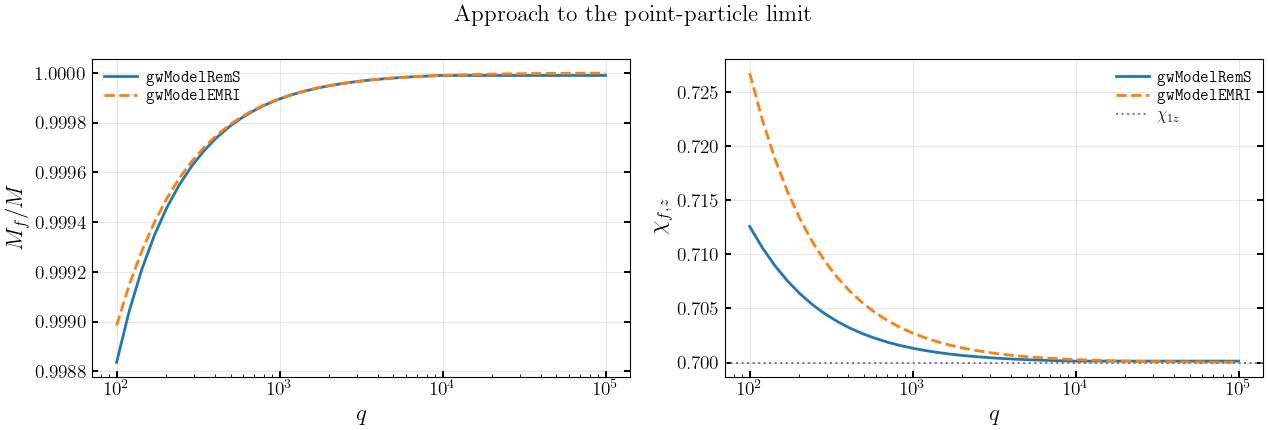

In [9]:
# Point-particle limit: compare against gwModelEMRI, which evaluates the
# exact Kerr test-particle result with no fitted terms
q_pp = np.logspace(2, 5, 40)
chi_pp = 0.7

Mf_S = gwModels.remnants.gwModelRemS_mf(np.minimum(q_pp, 10000.0), chi_pp, 0.0)
chif_S = gwModels.remnants.gwModelRemS_chif(np.minimum(q_pp, 10000.0), chi_pp, 0.0)
Mf_E, chif_E = gwModels.remnants.gwModelEMRI(q_pp, chi_pp, 0.0, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].semilogx(q_pp, Mf_S, lw=2, label=r'\texttt{gwModelRemS}')
axes[0].semilogx(q_pp, Mf_E, '--', lw=2, label=r'\texttt{gwModelEMRI}')
axes[0].set_xlabel('$q$')
axes[0].set_ylabel('$M_f/M$')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3)

axes[1].semilogx(q_pp, chif_S, lw=2, label=r'\texttt{gwModelRemS}')
axes[1].semilogx(q_pp, chif_E, '--', lw=2, label=r'\texttt{gwModelEMRI}')
axes[1].axhline(chi_pp, color='grey', ls=':', lw=1.5, label=r'$\chi_{1z}$')
axes[1].set_xlabel('$q$')
axes[1].set_ylabel(r'$\chi_{f,z}$')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3)

plt.suptitle('Approach to the point-particle limit')
plt.tight_layout()
plt.show()

### 4. Comparison with other remnant models in gwModels

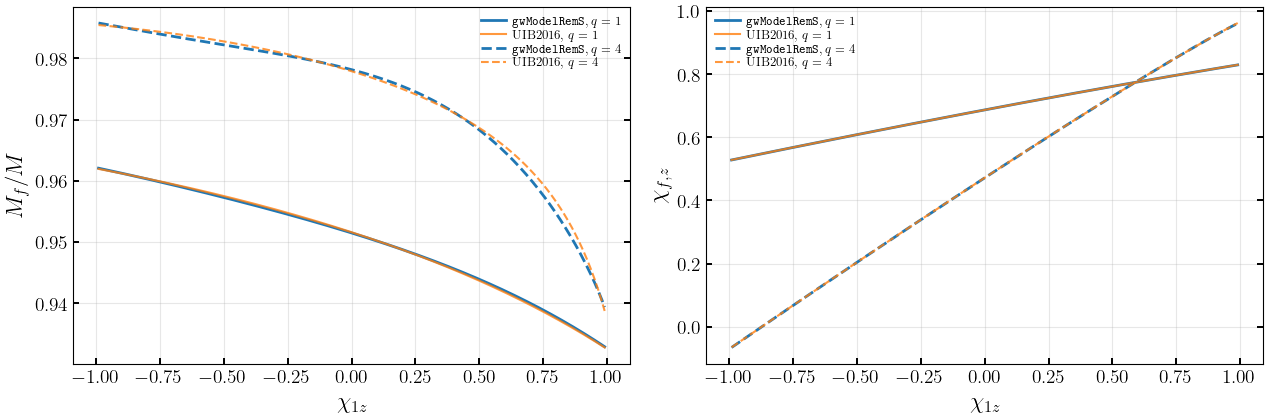

In [10]:
# Single-spin slice: chi2z = 0, sweep chi1z
chi1_arr = np.linspace(-0.99, 0.99, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for q_fix, ls in [(1.0, '-'), (4.0, '--')]:
    mf_s = gwModels.remnants.gwModelRemS_mf(q_fix, chi1_arr, 0.0)
    mf_u = gwModels.remnants.bbh_final_mass_non_precessing_UIB2016(q_fix, chi1_arr, 0.0)
    cf_s = gwModels.remnants.gwModelRemS_chif(q_fix, chi1_arr, 0.0)
    cf_u = gwModels.remnants.bbh_final_spin_non_precessing_UIB2016(q_fix, chi1_arr, 0.0)

    axes[0].plot(chi1_arr, mf_s, ls, lw=2, color='C0', label=rf'\texttt{{gwModelRemS}}, $q={q_fix:.0f}$')
    axes[0].plot(chi1_arr, mf_u, ls, lw=1.5, color='C1', alpha=0.8, label=rf'UIB2016, $q={q_fix:.0f}$')
    axes[1].plot(chi1_arr, cf_s, ls, lw=2, color='C0', label=rf'\texttt{{gwModelRemS}}, $q={q_fix:.0f}$')
    axes[1].plot(chi1_arr, cf_u, ls, lw=1.5, color='C1', alpha=0.8, label=rf'UIB2016, $q={q_fix:.0f}$')

axes[0].set_xlabel(r'$\chi_{1z}$')
axes[0].set_ylabel('$M_f/M$')
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel(r'$\chi_{1z}$')
axes[1].set_ylabel(r'$\chi_{f,z}$')
axes[1].legend(frameon=False, fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

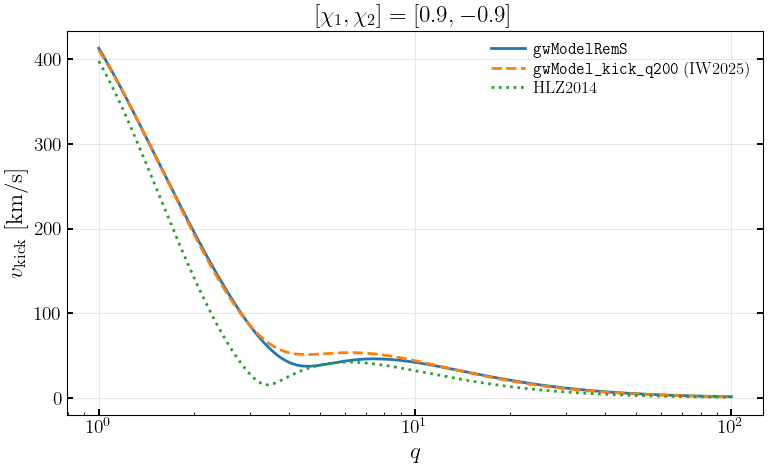

In [11]:
# Recoil: gwModelRemS vs HLZ2014 and the earlier gwModel_kick_q200
q_k = np.logspace(0, 2, 400)

plt.figure(figsize=(8, 5))
plt.semilogx(q_k, gwModels.remnants.gwModelRemS_kick(q_k, 0.9, -0.9),
             lw=2, label=r'\texttt{gwModelRemS}')
plt.semilogx(q_k, gwModels.remnants.gwModel_kick_q200(q_k, 0.9, -0.9),
             '--', lw=2, label=r'\texttt{gwModel\_kick\_q200} (IW2025)')
plt.semilogx(q_k, gwModels.remnants.bbh_final_kick_nonprecessing_HLZ2014(q_k, 0.9, -0.9),
             ':', lw=2, label='HLZ2014')

plt.xlabel('$q$')
plt.ylabel(r'$v_{\rm kick}$ [km/s]')
plt.title(r'$[\chi_1,\chi_2]=[0.9,-0.9]$')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5. Timing\n\nThe model is a closed-form polynomial evaluation, so cost is dominated by numpy array overhead and it vectorizes essentially for free.

In [12]:
sizes = [1, 10, 100, 1000, 10000, 100000]
means = []

for n in sizes:
    q_t = np.random.uniform(1, 10, n)
    c1_t = np.random.uniform(-0.9, 0.9, n)
    c2_t = np.random.uniform(-0.9, 0.9, n)
    reps = 20 if n <= 10000 else 5
    t = []
    for _ in range(reps):
        t0 = time.perf_counter()
        gwModels.remnants.gwModelRemS(q_t, c1_t, c2_t)
        t.append(time.perf_counter() - t0)
    means.append(np.mean(t))

means = np.array(means)
print(f'{'N':>8s}  {'time':>10s}  {'per binary':>13s}')
for n, m in zip(sizes, means):
    print(f'{n:>8d}  {m*1e3:8.3f} ms  {m/n*1e6:10.4f} us')

       N        time     per binary
       1     0.210 ms    210.0956 us
      10     0.208 ms     20.8442 us
     100     0.232 ms      2.3194 us
    1000     0.458 ms      0.4576 us
   10000     3.093 ms      0.3093 us
  100000    33.164 ms      0.3316 us


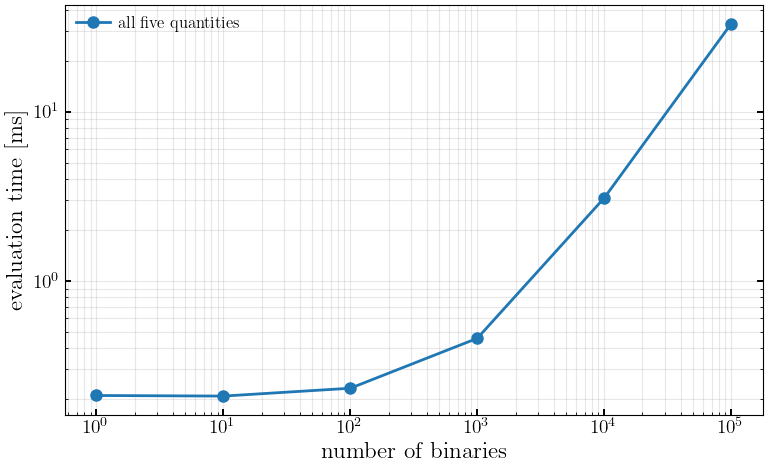

In [13]:
plt.figure(figsize=(8, 5))
plt.loglog(sizes, means * 1e3, 'o-', lw=2, ms=8, label='all five quantities')
plt.xlabel('number of binaries')
plt.ylabel('evaluation time [ms]')
plt.legend(frameon=False)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

In [14]:
# Cost of each quantity separately, for 10000 binaries
n = 10000
q_t = np.random.uniform(1, 10, n)
c1_t = np.random.uniform(-0.9, 0.9, n)
c2_t = np.random.uniform(-0.9, 0.9, n)

for name, fn in [
    ('mf', gwModels.remnants.gwModelRemS_mf),
    ('chif', gwModels.remnants.gwModelRemS_chif),
    ('Lpeak', gwModels.remnants.gwModelRemS_Lpeak),
    ('omega_peak', gwModels.remnants.gwModelRemS_omega_peak),
    ('kick', gwModels.remnants.gwModelRemS_kick),
]:
    t = []
    for _ in range(20):
        t0 = time.perf_counter()
        fn(q_t, c1_t, c2_t)
        t.append(time.perf_counter() - t0)
    print(f'  {name:>11s} : {np.mean(t)*1e3:7.3f} ms for {n} binaries')

           mf :   0.649 ms for 10000 binaries
         chif :   1.092 ms for 10000 binaries
        Lpeak :   0.364 ms for 10000 binaries
   omega_peak :   0.357 ms for 10000 binaries
         kick :   0.626 ms for 10000 binaries
